<a href="https://colab.research.google.com/github/inspire2029-sudo/phantoms-ai-week5/blob/main/W5D1_First_Neural_Network_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Training samples: 60000
Testing samples: 10000
Epoch 1/5 | Loss: 0.3328 | Accuracy: 94.82%
Epoch 2/5 | Loss: 0.1363 | Accuracy: 96.55%
Epoch 3/5 | Loss: 0.0947 | Accuracy: 96.98%
Epoch 4/5 | Loss: 0.0710 | Accuracy: 97.21%
Epoch 5/5 | Loss: 0.0545 | Accuracy: 97.50%

Model saved as: mnist_model.pth


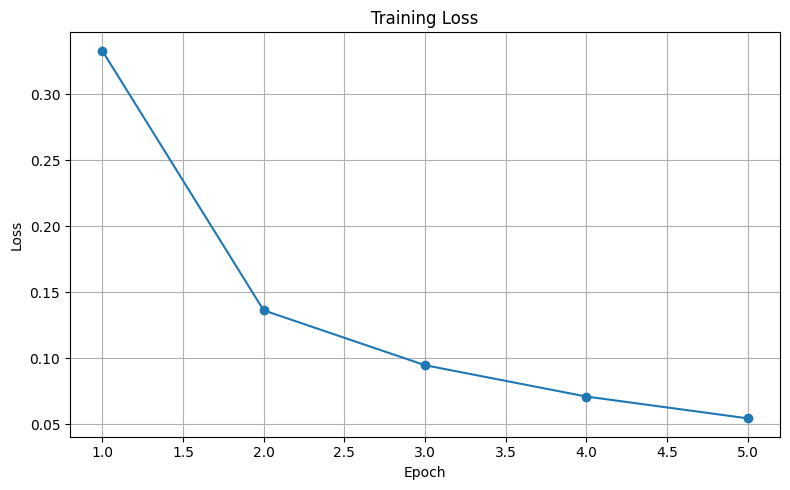

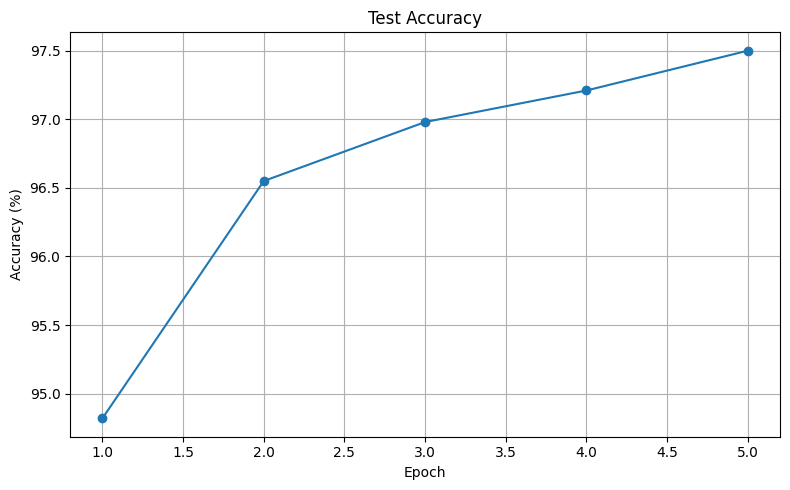

In [2]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================================
# 1. Configuration
# ============================================================

SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5

DATA_DIR = "data"


# ============================================================
# 2. Reproducibility
# ============================================================

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 3. Device Selection
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


# ============================================================
# 4. Data Transformation
# ============================================================

transform = transforms.ToTensor()


# ============================================================
# 5. Load MNIST Dataset
# ============================================================

train_data = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# 6. Create DataLoaders
# ============================================================

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")


# ============================================================
# 7. Define Neural Network
# ============================================================

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


model = MNISTClassifier().to(device)


# ============================================================
# 8. Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 9. Training and Evaluation
# ============================================================

train_losses = []
test_accuracies = []

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    total_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    train_losses.append(average_loss)

    # -------------------------
    # Evaluation
    # -------------------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)

            correct += (predictions == labels).sum().item()

    accuracy = 100 * correct / total

    test_accuracies.append(accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )


# ============================================================
# 10. Save Trained Model
# ============================================================

torch.save(
    model.state_dict(),
    "mnist_model.pth"
)

print("\nModel saved as: mnist_model.pth")


# ============================================================
# 11. Plot Training Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 12. Plot Test Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    test_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")

plt.grid(True)

plt.tight_layout()

plt.show()

في التاسك ده عملت أول Neural Network  عن طريق ال PyTorch لتصنيف صور الأرقام المكتوبة بخط اليد من MNIST Dataset



في البداية حملت بيانات التدريب والاختبار عن طريق MNIST وقسمت البيانات ل Batches باستخدام DataLoader عشان الشبكة تتعامل مع البيانات بشكل منظم وأسرع



بعد كده حولت الصور ل Tensors عن طريق ToTensor لأن ال PyTorch محتاج البيانات تكون في صورة مناسبة للتعامل معاها جوا ال Neural Network



كل صورة في MNIST حجمها 28 في 28 Pixel وعشان أقدر أدخلها على ال Fully Connected Layers استخدمت Flatten عشان أحول الصورة من 28 في 28 إلى 784 قيمة



بعد كده بنيت Fully Connected Neural Network مكونة من 3 Linear Layers أول Layer بتحول ال 784 Input ل 128 Neuron وبعدها استخدمت ReLU كـ Activation Function ثم Layer تانية بتحول 128 إلى 64 Neuron وبعدها ReLU ثم آخر Layer بتحول 64 إلى 10 Outputs لأن عندنا 10 Classes من الرقم 0 لحد الرقم 9



ال ReLU مهمة لأنها بتضيف Non Linearity للشبكة وبتخليها تقدر تتعلم Patterns وعلاقات أكتر تعقيدا بدل ما تكون الشبكة كلها مجرد عمليات خطية



بعد بناء الـ Model استخدمت CrossEntropyLoss علشان أحسب الفرق بين الـ Predictions اللي الشبكة بتطلعها والـ Labels الصحيحة



استخدمت Adam Optimizer علشان يعدل الـ Weights بتاعة الشبكة أثناء التدريب بناء على الـ Gradients اللي بتتحسب من خلال Backpropagation



أثناء كل Training Epoch البيانات بتمر على الشبكة في Forward Pass وبعد كده بيتحسب الـ Loss ثم بنعمل Backpropagation علشان نحسب الـ Gradients وبعدها الـ Optimizer بيحدث الـ Weights علشان الـ Model يتحسن مع التدريب



دربت الشبكة لمدة 5 Epochs وفي نهاية كل Epoch حسبت متوسط الـ Loss وحسبت الـ Accuracy على Test Dataset علشان أتابع أداء الشبكة على بيانات مش مستخدمة في التدريب



كمان سجلت قيم الـ Loss والـ Accuracy أثناء التدريب ورسمت منحنى للـ Training Loss ومنحنى للـ Test Accuracy علشان أقدر أتابع هل الشبكة بتتعلم وبتتحسن مع كل Epoch ولا لأ



وفي النهاية حفظت الـ Trained Model في ملف mnist_model.pth علشان أقدر أستخدم الـ Weights اللي اتعلمتها الشبكة بعد كده من غير ما أبدأ التدريب من الصفر



بالتالي التاسك غطى الأساسيات الرئيسية في بناء أول Neural Network وهي Dataset Preparation وForward Pass وActivation Functions وLoss Function وBackpropagation وOptimizer وTraining وEvaluation وVisualization